In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

# Basic overview
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDataset Shape:", df.shape)

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Dataset Shape: (999

In [ ]:
# Convert Order Date and Ship Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract useful time features
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%b')
df['Order Quarter'] = df['Order Date'].dt.quarter

# Create a Year-Month column for trend charts
df['Year-Month'] = df['Order Date'].dt.to_period('M').astype(str)

print("Date columns fixed!")
print(df[['Order Date', 'Order Year', 'Order Month', 'Order Quarter']].head())

Date columns fixed!
  Order Date  Order Year  Order Month  Order Quarter
0 2016-11-08        2016           11              4
1 2016-11-08        2016           11              4
2 2016-06-12        2016            6              2
3 2015-10-11        2015           10              4
4 2015-10-11        2015           10              4


In [ ]:
print("="*50)
print("KEY BUSINESS METRICS")
print("="*50)
print(f"Total Sales:         ₹{df['Sales'].sum():,.2f}")
print(f"Total Profit:        ₹{df['Profit'].sum():,.2f}")
print(f"Total Orders:        {df['Order ID'].nunique()}")
print(f"Total Customers:     {df['Customer ID'].nunique()}")
print(f"Total Products:      {df['Product ID'].nunique()}")
print(f"Profit Margin:       {(df['Profit'].sum()/df['Sales'].sum()*100):.2f}%")
print(f"Avg Order Value:     ₹{df.groupby('Order ID')['Sales'].sum().mean():,.2f}")
print(f"Date Range:          {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")

KEY BUSINESS METRICS
Total Sales:         ₹2,297,200.86
Total Profit:        ₹286,397.02
Total Orders:        5009
Total Customers:     793
Total Products:      1862
Profit Margin:       12.47%
Avg Order Value:     ₹458.61
Date Range:          2014-01-03 to 2017-12-30


In [ ]:
category_summary = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'nunique')
).reset_index()

category_summary['Profit Margin %'] = (
    category_summary['Total_Profit'] / category_summary['Total_Sales'] * 100
).round(2)

print("Sales & Profit by Category:")
print(category_summary)

Sales & Profit by Category:
          Category  Total_Sales  Total_Profit  Total_Orders  Profit Margin %
0        Furniture  741999.7953    18451.2728          1764             2.49
1  Office Supplies  719047.0320   122490.8008          3742            17.04
2       Technology  836154.0330   145454.9481          1544            17.40


In [ ]:
region_summary = df.groupby('Region').agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum')
).reset_index().sort_values('Total_Sales', ascending=False)

segment_summary = df.groupby('Segment').agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum')
).reset_index().sort_values('Total_Sales', ascending=False)

print("Sales by Region:")
print(region_summary)
print("\nSales by Segment:")
print(segment_summary)

Sales by Region:
    Region  Total_Sales  Total_Profit
3     West  725457.8245   108418.4489
1     East  678781.2400    91522.7800
0  Central  501239.8908    39706.3625
2    South  391721.9050    46749.4303

Sales by Segment:
       Segment   Total_Sales  Total_Profit
0     Consumer  1.161401e+06   134119.2092
1    Corporate  7.061464e+05    91979.1340
2  Home Office  4.296531e+05    60298.6785


In [ ]:
product_profit = df.groupby('Product Name')['Profit'].sum().reset_index()

top10 = product_profit.sort_values('Profit', ascending=False).head(10)
bottom10 = product_profit.sort_values('Profit').head(10)

print("TOP 10 Most Profitable Products:")
print(top10)
print("\nBOTTOM 10 Least Profitable Products (Losses):")
print(bottom10)

TOP 10 Most Profitable Products:
                                           Product Name      Profit
404               Canon imageCLASS 2200 Advanced Copier  25199.9280
650   Fellowes PB500 Electric Punch Plastic Comb Bin...   7753.0390
805                Hewlett Packard LaserJet 3310 Copier   6983.8836
400                  Canon PC1060 Personal Laser Copier   4570.9347
787   HP Designjet T520 Inkjet Large Format Printer ...   4094.9766
165                   Ativa V4110MDD Micro-Cut Shredder   3772.9461
19     3D Systems Cube Printer, 2nd Generation, Magenta   3717.9714
1276  Plantronics Savi W720 Multi-Device Wireless He...   3696.2820
895                Ibico EPK-21 Electric Binding System   3345.2823
1840                  Zebra ZM400 Thermal Label Printer   3343.5360

BOTTOM 10 Least Profitable Products (Losses):
                                           Product Name     Profit
475           Cubify CubeX 3D Printer Double Head Print -8879.9704
985           Lexmark MX611dhe Monochr

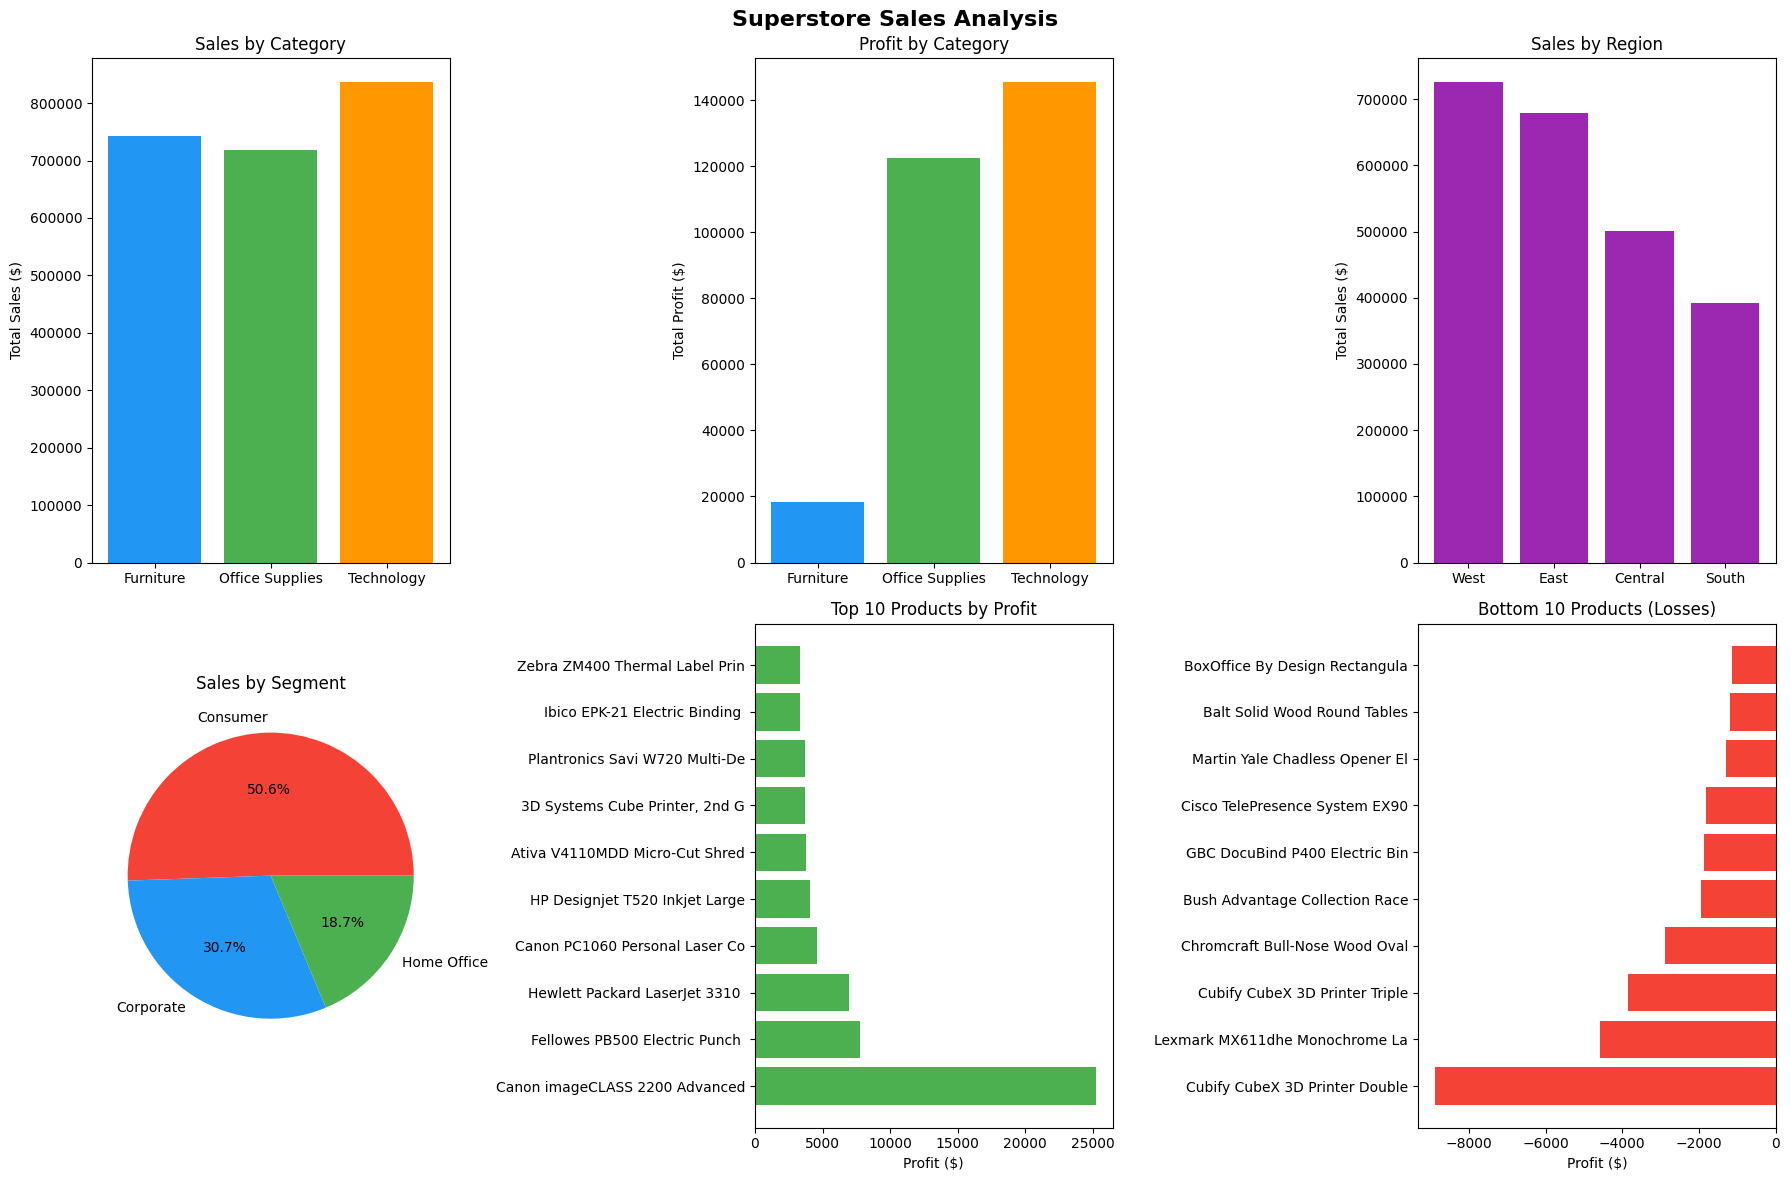

Chart saved!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Superstore Sales Analysis', fontsize=16, fontweight='bold')

# 1. Sales by Category
axes[0,0].bar(category_summary['Category'], category_summary['Total_Sales'], color=['#2196F3','#4CAF50','#FF9800'])
axes[0,0].set_title('Sales by Category')
axes[0,0].set_ylabel('Total Sales ($)')

# 2. Profit by Category
axes[0,1].bar(category_summary['Category'], category_summary['Total_Profit'], color=['#2196F3','#4CAF50','#FF9800'])
axes[0,1].set_title('Profit by Category')
axes[0,1].set_ylabel('Total Profit ($)')

# 3. Sales by Region
axes[0,2].bar(region_summary['Region'], region_summary['Total_Sales'], color='#9C27B0')
axes[0,2].set_title('Sales by Region')
axes[0,2].set_ylabel('Total Sales ($)')

# 4. Sales by Segment (Pie)
axes[1,0].pie(segment_summary['Total_Sales'], labels=segment_summary['Segment'],
              autopct='%1.1f%%', colors=['#F44336','#2196F3','#4CAF50'])
axes[1,0].set_title('Sales by Segment')

# 5. Top 10 Products by Profit
axes[1,1].barh(top10['Product Name'].str[:30], top10['Profit'], color='#4CAF50')
axes[1,1].set_title('Top 10 Products by Profit')
axes[1,1].set_xlabel('Profit ($)')

# 6. Bottom 10 Products by Profit
axes[1,2].barh(bottom10['Product Name'].str[:30], bottom10['Profit'], color='#F44336')
axes[1,2].set_title('Bottom 10 Products (Losses)')
axes[1,2].set_xlabel('Profit ($)')

plt.tight_layout()
plt.savefig('superstore_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

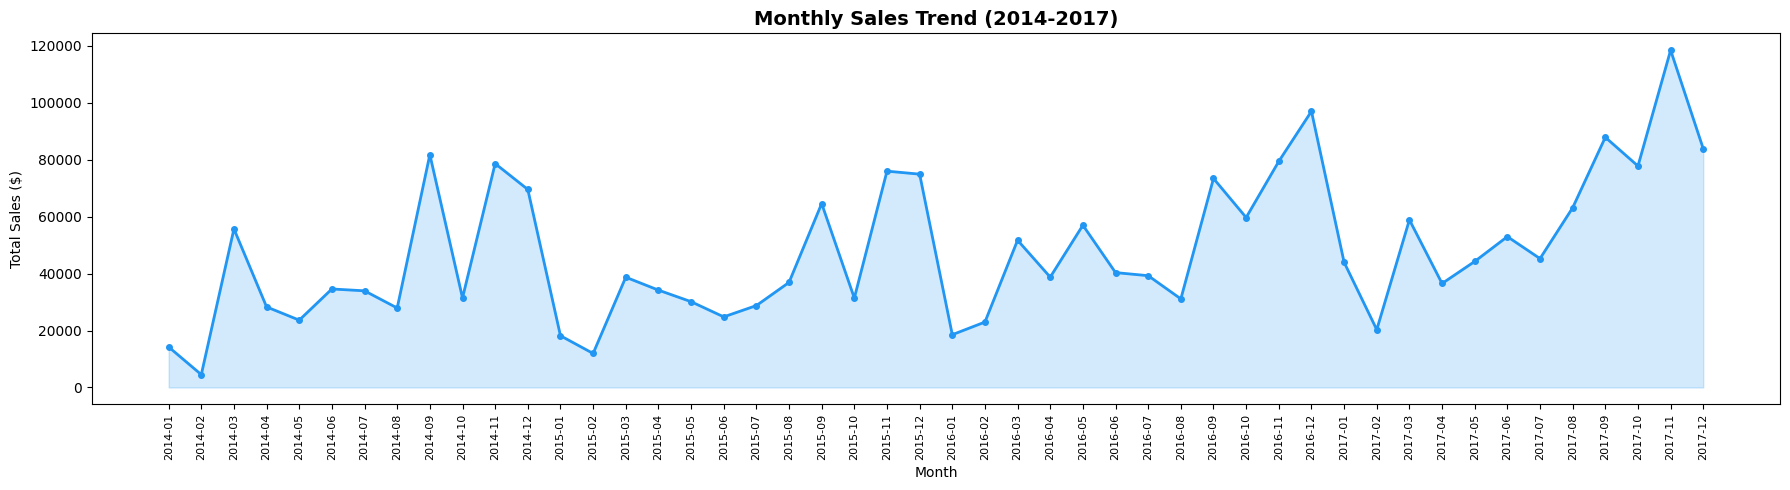

In [ ]:
monthly_sales = df.groupby('Year-Month')['Sales'].sum().reset_index()
monthly_sales = monthly_sales.sort_values('Year-Month')

plt.figure(figsize=(18,5))
plt.plot(monthly_sales['Year-Month'], monthly_sales['Sales'],
         marker='o', color='#2196F3', linewidth=2, markersize=4)
plt.fill_between(range(len(monthly_sales)), monthly_sales['Sales'], alpha=0.2, color='#2196F3')
plt.xticks(range(len(monthly_sales)), monthly_sales['Year-Month'], rotation=90, fontsize=8)
plt.title('Monthly Sales Trend (2014-2017)', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

Discount Impact on Profit:
  Discount Bucket  Avg_Profit  Total_Orders   Total_Sales
0     No Discount   66.900292          4798  1.087908e+06
1           0-20%   26.501571          3803  8.465222e+05
2          20-40%  -77.864055           460  2.341379e+05
3          40-60% -134.624160           215  7.104821e+04
4            60%+  -98.348741           718  5.758404e+04


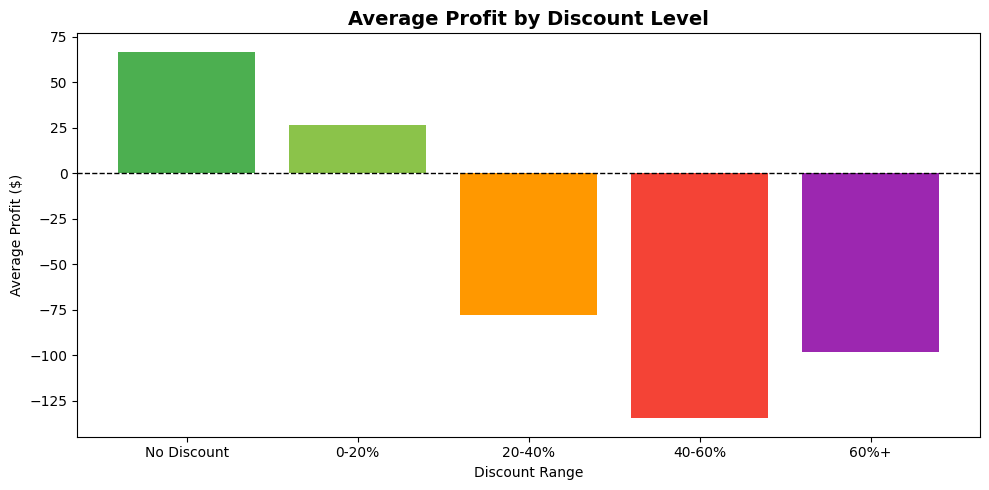

In [ ]:
# Create discount buckets
df['Discount Bucket'] = pd.cut(df['Discount'],
                                bins=[-0.1, 0, 0.2, 0.4, 0.6, 1.0],
                                labels=['No Discount','0-20%','20-40%','40-60%','60%+'])

discount_impact = df.groupby('Discount Bucket').agg(
    Avg_Profit=('Profit','mean'),
    Total_Orders=('Order ID','count'),
    Total_Sales=('Sales','sum')
).reset_index()

print("Discount Impact on Profit:")
print(discount_impact)

plt.figure(figsize=(10,5))
colors = ['#4CAF50','#8BC34A','#FF9800','#F44336','#9C27B0']
plt.bar(discount_impact['Discount Bucket'], discount_impact['Avg_Profit'], color=colors)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Average Profit by Discount Level', fontsize=14, fontweight='bold')
plt.ylabel('Average Profit ($)')
plt.xlabel('Discount Range')
plt.tight_layout()
plt.savefig('discount_impact.png', dpi=150)
plt.show()

Sub-Category Performance:
           Category Sub-Category  Total_Sales  Total_Profit  Total_Orders  Profit Margin %
14       Technology      Copiers  149528.0300    55617.8249            68            37.20
16       Technology       Phones  330007.0540    44515.7306           889            13.49
13       Technology  Accessories  167380.3180    41936.6357           775            25.05
10  Office Supplies        Paper   78479.2060    34053.5693          1370            43.39
6   Office Supplies      Binders  203412.7330    30221.7633          1523            14.86
1         Furniture       Chairs  328449.1030    26590.1663           617             8.10
11  Office Supplies      Storage  223843.6080    21278.8264           846             9.51
4   Office Supplies   Appliances  107532.1610    18138.0054           466            16.87
2         Furniture  Furnishings   91705.1640    13059.1436           957            14.24
7   Office Supplies    Envelopes   16476.4020     6964.1767     

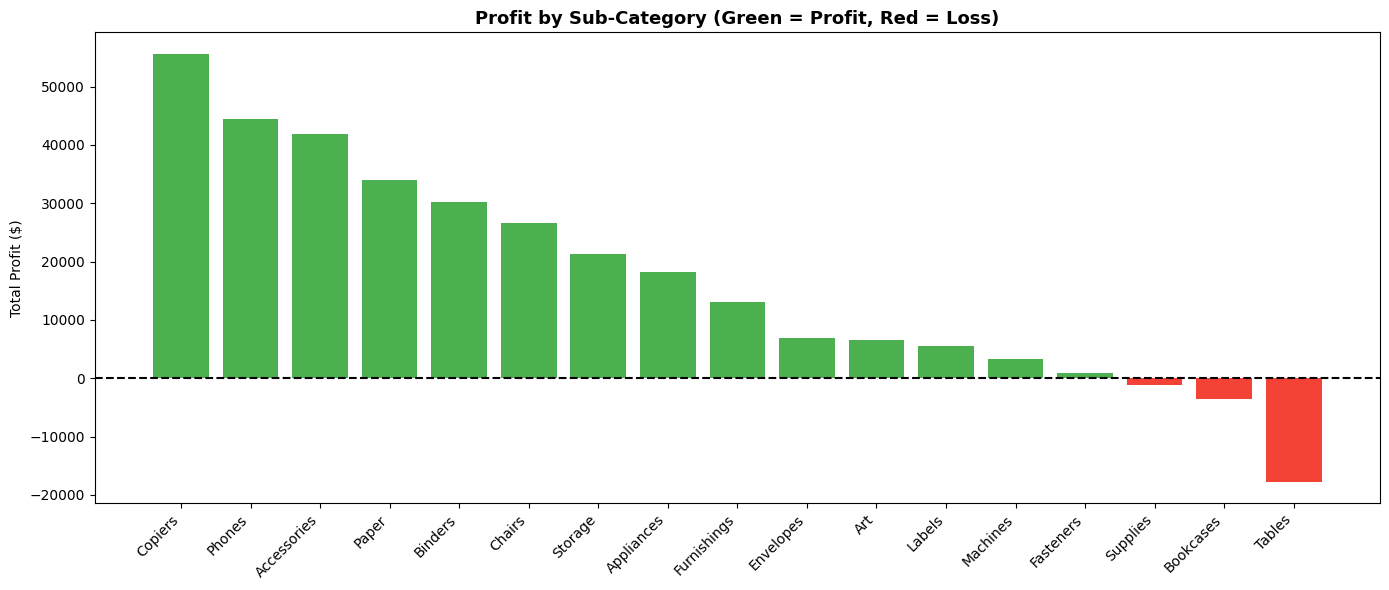

In [ ]:
subcat = df.groupby(['Category','Sub-Category']).agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum'),
    Total_Orders=('Order ID','count')
).reset_index()

subcat['Profit Margin %'] = (subcat['Total_Profit']/subcat['Total_Sales']*100).round(2)
subcat = subcat.sort_values('Total_Profit', ascending=False)

print("Sub-Category Performance:")
print(subcat.to_string())

# Chart
plt.figure(figsize=(14,6))
colors = ['#4CAF50' if x > 0 else '#F44336' for x in subcat['Total_Profit']]
plt.bar(subcat['Sub-Category'], subcat['Total_Profit'], color=colors)
plt.axhline(y=0, color='black', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.title('Profit by Sub-Category (Green = Profit, Red = Loss)', fontsize=13, fontweight='bold')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('subcategory_profit.png', dpi=150)
plt.show()

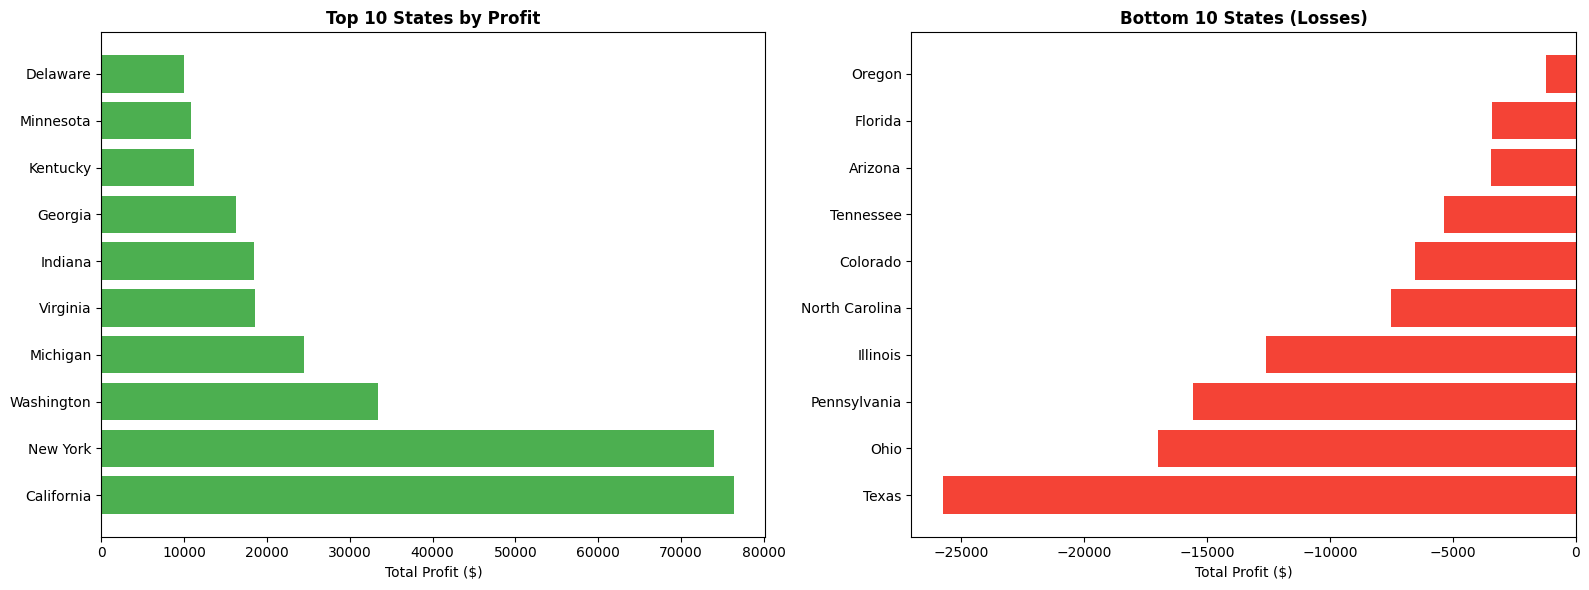


Top 5 Profit States:
         State  Total_Sales  Total_Profit  Profit Margin %
3   California  457687.6315    76381.3871            16.69
30    New York  310876.2710    74038.5486            23.82
45  Washington  138641.2700    33402.6517            24.09
20    Michigan   76269.6140    24463.1876            32.07
44    Virginia   70636.7200    18597.9504            26.33

Top 5 Loss States:
             State  Total_Sales  Total_Profit  Profit Margin %
41           Texas  170188.0458   -25729.3563           -15.12
33            Ohio   78258.1360   -16971.3766           -21.69
36    Pennsylvania  116511.9140   -15559.9603           -13.35
11        Illinois   80166.1010   -12607.8870           -15.73
31  North Carolina   55603.1640    -7490.9122           -13.47


In [ ]:
state_perf = df.groupby('State').agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum')
).reset_index()

state_perf['Profit Margin %'] = (state_perf['Total_Profit']/state_perf['Total_Sales']*100).round(2)

# Top 10 states by profit
top_states = state_perf.sort_values('Total_Profit', ascending=False).head(10)
# Bottom 10 states by profit
loss_states = state_perf.sort_values('Total_Profit').head(10)

fig, axes = plt.subplots(1, 2, figsize=(16,6))

axes[0].barh(top_states['State'], top_states['Total_Profit'], color='#4CAF50')
axes[0].set_title('Top 10 States by Profit', fontweight='bold')
axes[0].set_xlabel('Total Profit ($)')

axes[1].barh(loss_states['State'], loss_states['Total_Profit'], color='#F44336')
axes[1].set_title('Bottom 10 States (Losses)', fontweight='bold')
axes[1].set_xlabel('Total Profit ($)')

plt.tight_layout()
plt.savefig('state_performance.png', dpi=150)
plt.show()

print("\nTop 5 Profit States:")
print(top_states[['State','Total_Sales','Total_Profit','Profit Margin %']].head())
print("\nTop 5 Loss States:")
print(loss_states[['State','Total_Sales','Total_Profit','Profit Margin %']].head())

In [ ]:
# Select important columns for Power BI
df_powerbi = df[[
    'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
    'Customer ID', 'Customer Name', 'Segment', 'Region', 'State', 'City',
    'Category', 'Sub-Category', 'Product Name',
    'Sales', 'Quantity', 'Discount', 'Profit',
    'Order Year', 'Order Month', 'Order Month Name',
    'Order Quarter', 'Year-Month', 'Discount Bucket'
]].copy()

df_powerbi.to_csv('superstore_clean.csv', index=False)
print("✅ Clean data exported as 'superstore_clean.csv'")
print(f"Shape: {df_powerbi.shape}")
print("\nColumns exported:")
print(df_powerbi.columns.tolist())

✅ Clean data exported as 'superstore_clean.csv'
Shape: (9994, 23)

Columns exported:
['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Region', 'State', 'City', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order Year', 'Order Month', 'Order Month Name', 'Order Quarter', 'Year-Month', 'Discount Bucket']


Customer Segments:
     Segment  Count
0      Loyal    222
1   Champion    193
2  Potential    182
3    At Risk    141
4       Lost     55


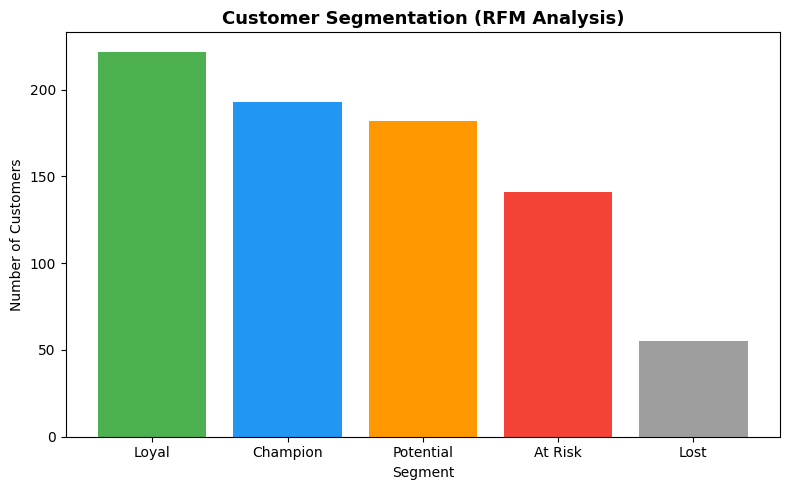


✅ RFM data exported as 'rfm_segments.csv'


In [ ]:
# Latest date in dataset
latest_date = df['Order Date'].max()

rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda x: (latest_date - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum')
).reset_index()

# Score each metric 1-4
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1,2,3,4]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# Segment customers
def segment(score):
    if score >= 10:
        return 'Champion'
    elif score >= 8:
        return 'Loyal'
    elif score >= 6:
        return 'Potential'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

print("Customer Segments:")
print(segment_counts)

plt.figure(figsize=(8,5))
colors = ['#4CAF50','#2196F3','#FF9800','#F44336','#9E9E9E']
plt.bar(segment_counts['Segment'], segment_counts['Count'], color=colors)
plt.title('Customer Segmentation (RFM Analysis)', fontsize=13, fontweight='bold')
plt.ylabel('Number of Customers')
plt.xlabel('Segment')
plt.tight_layout()
plt.savefig('customer_segments.png', dpi=150)
plt.show()

# Export RFM for Power BI
rfm.to_csv('rfm_segments.csv', index=False)
print("\n✅ RFM data exported as 'rfm_segments.csv'")